# Реконструкция по двум проекциям: воспроизводимый пример

Синтетический тест с известным 3D-ответом. Истинный объём используется только для итоговой оценки. В оптимизацию поступают матрицы XZ и YZ.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from reconstruction import rasterize, project, fit_geometry, fit_energy, permutation_candidates
from reconstruction.demo import synthetic_event, iou

In [2]:
truth_geometry, truth_energy, xz, yz = synthetic_event()
best, models = fit_geometry(xz, yz, max_branches=2, maxiter=20)
[(m["branches"], round(m["projection_chamfer"], 4), round(m["selection_score"], 4)) for m in models]

[(0, 3.2273, 3.2273), (1, 1.6021, 1.7521), (2, 0.0, 0.3)]

In [3]:
candidates = []
for geometry in permutation_candidates(best["geometry"]):
    mask = rasterize(geometry)
    energy, diagnostics = fit_energy(mask, xz, yz)
    candidates.append((diagnostics["xz_mse"] + diagnostics["yz_mse"], mask, energy, diagnostics))
score, mask, energy, diagnostics = min(candidates, key=lambda item: item[0])
print(f"Число перестановок: {len(candidates)}")
print(f"IoU 3D-маски после выбора по энергии: {iou(mask, truth_energy > 0):.3f}")
print(f"MSE проекций: XZ={diagnostics['xz_mse']:.6g}, YZ={diagnostics['yz_mse']:.6g}")

Число перестановок: 2
IoU 3D-маски после выбора по энергии: 1.000
MSE проекций: XZ=3.18836e-06, YZ=3.18836e-06


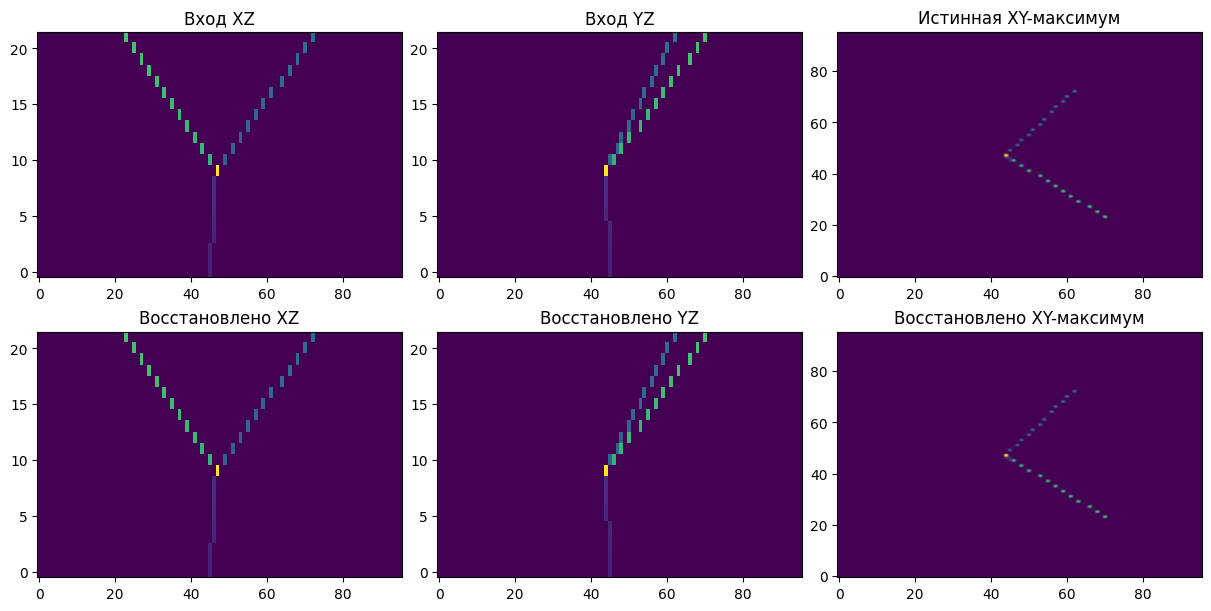

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)
images = [xz, yz, truth_energy.max(axis=0), *project(energy), energy.max(axis=0)]
titles = ["Вход XZ", "Вход YZ", "Истинная XY-максимум", "Восстановлено XZ", "Восстановлено YZ", "Восстановлено XY-максимум"]
for ax, arr, title in zip(axes.flat, images, titles):
    ax.imshow(arr, origin="lower", aspect="auto")
    ax.set_title(title)
plt.show()

**Ограничение:** точное восстановление в этом примере зависит от простых прямых треков, сильного пика в точке взаимодействия и различимых энергетических профилей ветвей. Для реальных данных нужны отдельные испытания и настройка модели.